# Model Training, Test Evaluation, and SHAP

This notebook trains models using `output.csv`, evaluates them on `test.csv`, and interprets the trained models with SHAP.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [23]:
base_dir = Path(r'C:\Users\junhyun111\Desktop\mf')
train_path = base_dir / 'model' / 'output.csv'
test_path = base_dir / 'test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f'Train path: {train_path}')
print(f'Test path: {test_path}')
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

display(train_df.head())
display(test_df.head())

Train path: C:\Users\junhyun111\Desktop\mf\model\output.csv
Test path: C:\Users\junhyun111\Desktop\mf\test.csv
Train shape: (97, 34)
Test shape: (10, 34)


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,sample_id,valid_physics,status_detail,n_cycles,status,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail
0,121.2316,0.2423,0.0118,64.8647,38.0086,27.9062,0.9887,7.9748,0.0793,0.1830,0.8170,0.8404,0.8957,0.9452,1.0589,0.5228,0.1639,0.6379,1,True,ok,10,ok,0.0469,0.2094,0.0299,0.1526,11.2558,0.1496,11.4607,0.7990,0.2010,0.2049,0.0515
1,163.8069,0.3384,0.0286,59.6933,65.9540,9.6816,0.8841,6.0191,0.0871,0.2356,0.7644,0.8666,0.9131,0.9520,1.0564,0.4160,0.4905,0.6927,2,True,ok,10,ok,0.1983,0.6436,0.1374,0.1427,7.0307,0.1294,7.1476,0.6962,0.3038,0.1169,0.0510
2,82.4720,0.2309,0.0221,50.1682,40.9718,43.9300,0.1383,2.1531,0.0492,0.1979,0.8021,0.8944,0.9384,0.9685,1.0347,0.3555,0.2280,0.6901,3,True,ok,10,ok,0.0648,0.2624,0.0447,0.1514,12.0743,0.1469,12.2633,0.7893,0.2107,0.1891,0.0505
3,96.3668,0.1627,0.0211,53.2543,26.8107,57.5443,0.7232,7.3361,0.0480,0.2499,0.7501,0.8478,0.9018,0.9527,1.0451,0.5145,0.3179,0.7227,4,True,ok,10,ok,0.0914,0.2743,0.0661,0.1418,14.9887,0.1402,15.1518,0.7810,0.2190,0.1631,0.0457
4,113.6140,0.1801,0.0315,20.3417,60.8850,44.6156,0.0201,9.7885,0.0337,0.2159,0.7841,0.8832,0.9322,0.9737,1.0430,0.4075,0.3891,0.7082,5,True,ok,10,ok,0.1390,0.5049,0.0985,0.1546,13.5221,0.1476,13.6359,0.7006,0.2994,0.1138,0.0486


,sample_id,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail,valid_physics,status_detail,n_cycles,status
0,1,179.5262,0.2402,0.0283,44.0400,45.9644,97.1247,0.2390,5.6130,0.0618,0.1609,0.8390,0.8652,0.9211,0.9599,1.0490,0.4707,0.3562,0.6297,0.1472,0.7675,0.0927,0.1675,8.9668,0.1585,9.0722,0.6630,0.3370,0.1055,0.0536,True,ok,10,ok
1,2,104.6421,0.3263,0.0147,26.1655,42.7460,3.9634,0.8382,4.4564,0.0286,0.2321,0.7679,0.8949,0.9250,0.9661,1.0252,0.3061,0.2409,0.7123,0.0642,0.2123,0.0457,0.1441,8.7230,0.1385,8.9183,0.7947,0.2053,0.1953,0.0505,True,ok,10,ok
2,3,83.2845,0.1922,0.0196,53.9784,62.2878,36.9737,0.3895,9.3729,0.0144,0.2019,0.7980,0.8719,0.9180,0.9684,1.0331,0.4352,0.2120,0.6855,0.0594,0.2347,0.0407,0.1513,13.8917,0.1471,14.0863,0.7981,0.2019,0.1946,0.0492,True,ok,10,ok
3,4,157.8853,0.2417,0.0147,46.9414,44.6750,68.5105,0.1834,2.6521,0.0727,0.1693,0.8307,0.8798,0.9314,0.9615,1.0472,0.4121,0.2261,0.6487,0.0707,0.3470,0.0459,0.1571,11.0040,0.1529,11.1647,0.7529,0.2471,0.1607,0.0527,True,ok,10,ok
4,5,77.1339,0.1732,0.0254,36.2192,48.6656,20.1029,0.6621,5.8664,0.0133,0.1858,0.8142,0.8774,0.9167,0.9649,1.0243,0.3959,0.2221,0.6788,0.0654,0.2866,0.0444,0.1556,14.7817,0.1516,14.9556,0.7770,0.2230,0.1739,0.0499,True,ok,10,ok


In [24]:
feature_cols = [
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'h2o_ppmv', 'sox_ppmv', 'nox_ppmv', 'dust_mg_Nm3',
    'co2_mol_frac','capacity_factor', 'affinity_factor_co2', 
    'mtc_factor', 'dax_factor', 'deactivation_index'
]

target_cols = ['CO2_purity', 'CO2_recovery']

required_train_cols = feature_cols + target_cols
required_test_cols = feature_cols + target_cols

missing_train = [col for col in required_train_cols if col not in train_df.columns]
missing_test = [col for col in required_test_cols if col not in test_df.columns]

if missing_train:
    raise ValueError(f'Missing train columns: {missing_train}')
if missing_test:
    raise ValueError(f'Missing test columns: {missing_test}')

display(pd.DataFrame({'feature_cols': feature_cols}))

,feature_cols
0,tADS
1,PL
2,v0
3,t_press
4,t_depress
5,h2o_ppmv
6,sox_ppmv
7,nox_ppmv
8,dust_mg_Nm3
9,co2_mol_frac


In [25]:
# Keep only physically valid rows if flags are present
train_clean = train_df.copy()
test_clean = test_df.copy()

if 'valid_physics' in train_clean.columns:
    train_clean = train_clean[train_clean['valid_physics'].fillna(False)].copy()
if 'status' in train_clean.columns:
    train_clean = train_clean[train_clean['status'].eq('ok')].copy()

if 'valid_physics' in test_clean.columns:
    test_clean = test_clean[test_clean['valid_physics'].fillna(False)].copy()
if 'status' in test_clean.columns:
    test_clean = test_clean[test_clean['status'].eq('ok')].copy()

train_clean = train_clean.dropna(subset=required_train_cols).reset_index(drop=True)
test_clean = test_clean.dropna(subset=required_test_cols).reset_index(drop=True)

print(f'Filtered train shape: {train_clean.shape}')
print(f'Filtered test shape: {test_clean.shape}')

Filtered train shape: (97, 34)
Filtered test shape: (10, 34)


In [26]:
X_train = train_clean[feature_cols].copy()
X_test = test_clean[feature_cols].copy()

y_train_purity = train_clean['CO2_purity'].copy()
y_train_recovery = train_clean['CO2_recovery'].copy()
y_test_purity = test_clean['CO2_purity'].copy()
y_test_recovery = test_clean['CO2_recovery'].copy()

display(X_train.head())

,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index
0,121.2316,0.2423,0.0118,64.8647,38.0086,27.9062,0.9887,7.9748,0.0793,0.1830,0.8404,0.8957,0.9452,1.0589,0.5228
1,163.8069,0.3384,0.0286,59.6933,65.9540,9.6816,0.8841,6.0191,0.0871,0.2356,0.8666,0.9131,0.9520,1.0564,0.4160
2,82.4720,0.2309,0.0221,50.1682,40.9718,43.9300,0.1383,2.1531,0.0492,0.1979,0.8944,0.9384,0.9685,1.0347,0.3555
3,96.3668,0.1627,0.0211,53.2543,26.8107,57.5443,0.7232,7.3361,0.0480,0.2499,0.8478,0.9018,0.9527,1.0451,0.5145
4,113.6140,0.1801,0.0315,20.3417,60.8850,44.6156,0.0201,9.7885,0.0337,0.2159,0.8832,0.9322,0.9737,1.0430,0.4075


In [27]:
# Train separate tree models for each target
purity_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

recovery_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

purity_model.fit(X_train, y_train_purity)
recovery_model.fit(X_train, y_train_recovery)

print('Training complete.')

Training complete.


In [28]:
y_pred_purity = purity_model.predict(X_test)
y_pred_recovery = recovery_model.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

purity_metrics = regression_metrics(y_test_purity, y_pred_purity)
recovery_metrics = regression_metrics(y_test_recovery, y_pred_recovery)

metrics_df = pd.DataFrame([
    {'target': 'CO2_purity', **purity_metrics},
    {'target': 'CO2_recovery', **recovery_metrics}
])

display(metrics_df)

,target,MAE,RMSE,R2
0,CO2_purity,0.0314,0.0373,0.7734
1,CO2_recovery,0.0122,0.0162,0.7524


In [29]:
results_df = test_clean.copy()
results_df['pred_CO2_purity'] = y_pred_purity
results_df['pred_CO2_recovery'] = y_pred_recovery
results_df['purity_error'] = results_df['CO2_purity'] - results_df['pred_CO2_purity']
results_df['recovery_error'] = results_df['CO2_recovery'] - results_df['pred_CO2_recovery']

display(results_df[['sample_id', 'CO2_purity', 'pred_CO2_purity', 'purity_error', 'CO2_recovery', 'pred_CO2_recovery', 'recovery_error']])

,sample_id,CO2_purity,pred_CO2_purity,purity_error,CO2_recovery,pred_CO2_recovery,recovery_error
0,1,0.3562,0.3111,0.0452,0.6297,0.6310,-0.0013
1,2,0.2409,0.2627,-0.0219,0.7123,0.7068,0.0055
2,3,0.2120,0.2342,-0.0223,0.6855,0.6806,0.0049
3,4,0.2261,0.2159,0.0101,0.6487,0.6415,0.0072
4,5,0.2221,0.2602,-0.0382,0.6788,0.6500,0.0288
5,6,0.3488,0.3367,0.0121,0.6932,0.6572,0.0360
6,7,0.3708,0.3378,0.0330,0.6751,0.6857,-0.0106
7,8,0.2460,0.2604,-0.0143,0.6711,0.6769,-0.0058
8,9,0.4030,0.3214,0.0816,0.7441,0.7325,0.0116
9,10,0.4214,0.3862,0.0352,0.7246,0.7145,0.0101


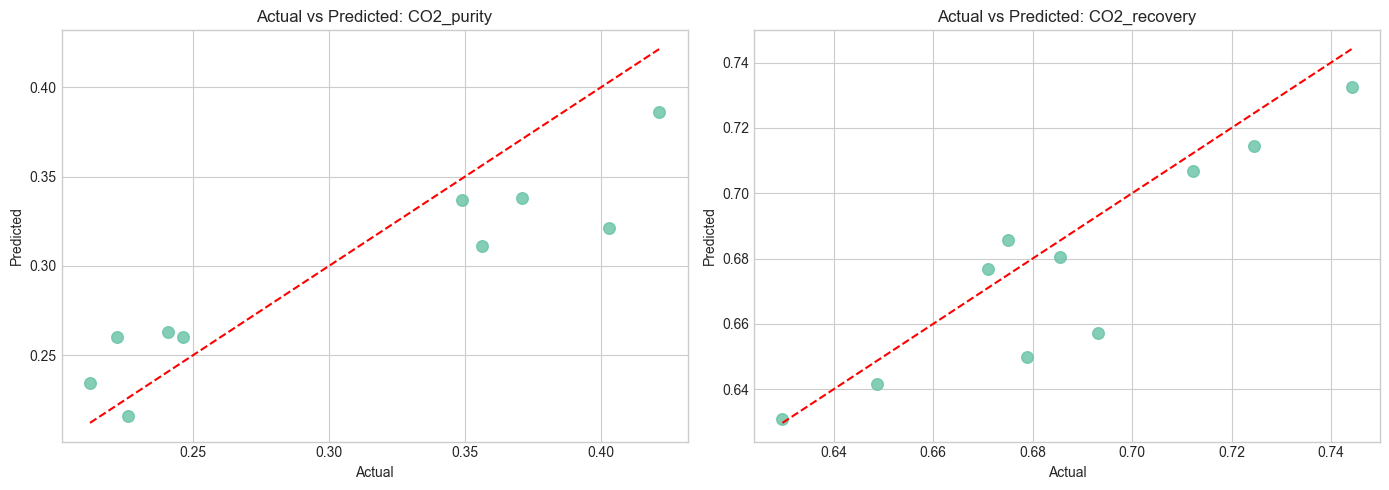

In [30]:
# Actual vs predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

purity_min = min(y_test_purity.min(), y_pred_purity.min())
purity_max = max(y_test_purity.max(), y_pred_purity.max())
axes[0].scatter(y_test_purity, y_pred_purity, s=70, alpha=0.8)
axes[0].plot([purity_min, purity_max], [purity_min, purity_max], color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted: CO2_purity')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

recovery_min = min(y_test_recovery.min(), y_pred_recovery.min())
recovery_max = max(y_test_recovery.max(), y_pred_recovery.max())
axes[1].scatter(y_test_recovery, y_pred_recovery, s=70, alpha=0.8)
axes[1].plot([recovery_min, recovery_max], [recovery_min, recovery_max], color='red', linestyle='--')
axes[1].set_title('Actual vs Predicted: CO2_recovery')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

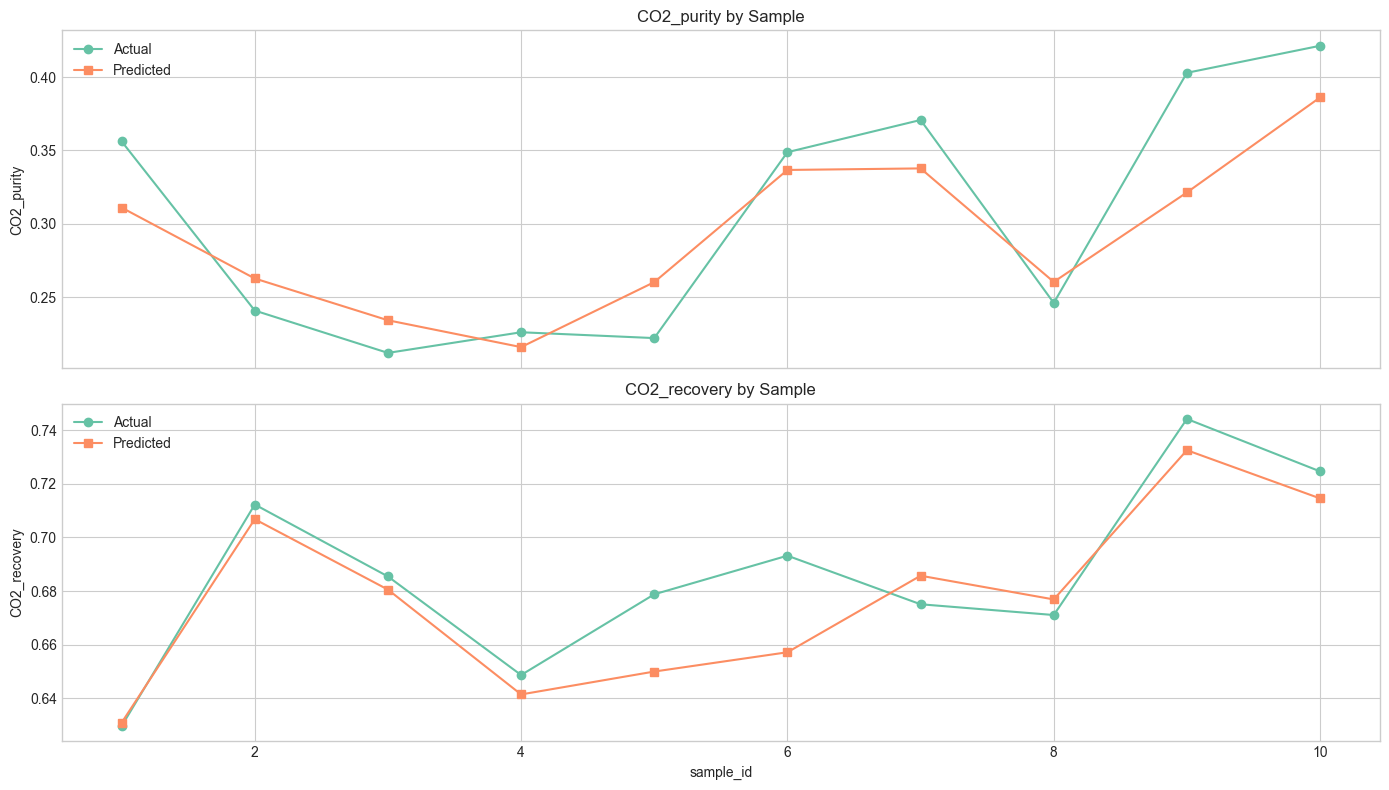

In [31]:
# Sample-wise comparison
sample_axis = results_df['sample_id'] if 'sample_id' in results_df.columns else np.arange(len(results_df))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sample_axis, y_test_purity.values, marker='o', label='Actual')
axes[0].plot(sample_axis, y_pred_purity, marker='s', label='Predicted')
axes[0].set_title('CO2_purity by Sample')
axes[0].set_ylabel('CO2_purity')
axes[0].legend()

axes[1].plot(sample_axis, y_test_recovery.values, marker='o', label='Actual')
axes[1].plot(sample_axis, y_pred_recovery, marker='s', label='Predicted')
axes[1].set_title('CO2_recovery by Sample')
axes[1].set_ylabel('CO2_recovery')
axes[1].set_xlabel('sample_id')
axes[1].legend()

plt.tight_layout()
plt.show()

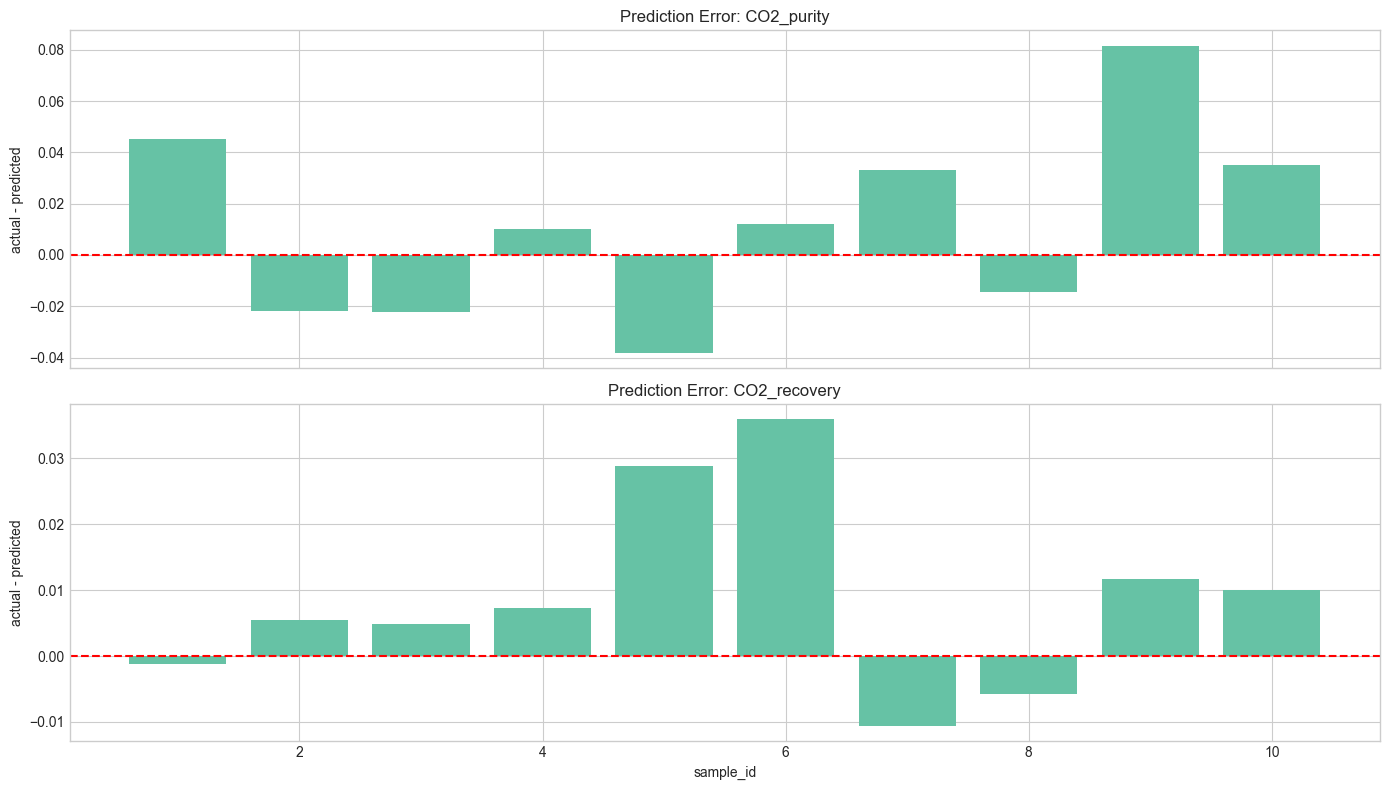

In [32]:
# Prediction error bar charts
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(sample_axis, results_df['purity_error'])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Prediction Error: CO2_purity')
axes[0].set_ylabel('actual - predicted')

axes[1].bar(sample_axis, results_df['recovery_error'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Prediction Error: CO2_recovery')
axes[1].set_ylabel('actual - predicted')
axes[1].set_xlabel('sample_id')

plt.tight_layout()
plt.show()

In [33]:
# Model-native feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'purity_importance': purity_model.feature_importances_,
    'recovery_importance': recovery_model.feature_importances_
})

display(importance_df.sort_values('purity_importance', ascending=False))
display(importance_df.sort_values('recovery_importance', ascending=False))

,feature,purity_importance,recovery_importance
2,v0,0.3813,0.0050
9,co2_mol_frac,0.2949,0.7705
0,tADS,0.2024,0.0071
1,PL,0.0227,0.0700
8,dust_mg_Nm3,0.0119,0.0049
4,t_depress,0.0116,0.0063
5,h2o_ppmv,0.0112,0.0115
3,t_press,0.0112,0.0261
14,deactivation_index,0.0104,0.0220
13,dax_factor,0.0103,0.0044


,feature,purity_importance,recovery_importance
9,co2_mol_frac,0.2949,0.7705
1,PL,0.0227,0.0700
3,t_press,0.0112,0.0261
14,deactivation_index,0.0104,0.0220
11,affinity_factor_co2,0.0037,0.0177
12,mtc_factor,0.0068,0.0175
10,capacity_factor,0.0050,0.0174
5,h2o_ppmv,0.0112,0.0115
7,nox_ppmv,0.0085,0.0105
6,sox_ppmv,0.0081,0.0090


In [34]:
# SHAP analysis
explainer_purity = shap.TreeExplainer(purity_model)
explainer_recovery = shap.TreeExplainer(recovery_model)

shap_values_purity = explainer_purity.shap_values(X_test)
shap_values_recovery = explainer_recovery.shap_values(X_test)

print('SHAP computation complete.')

SHAP computation complete.


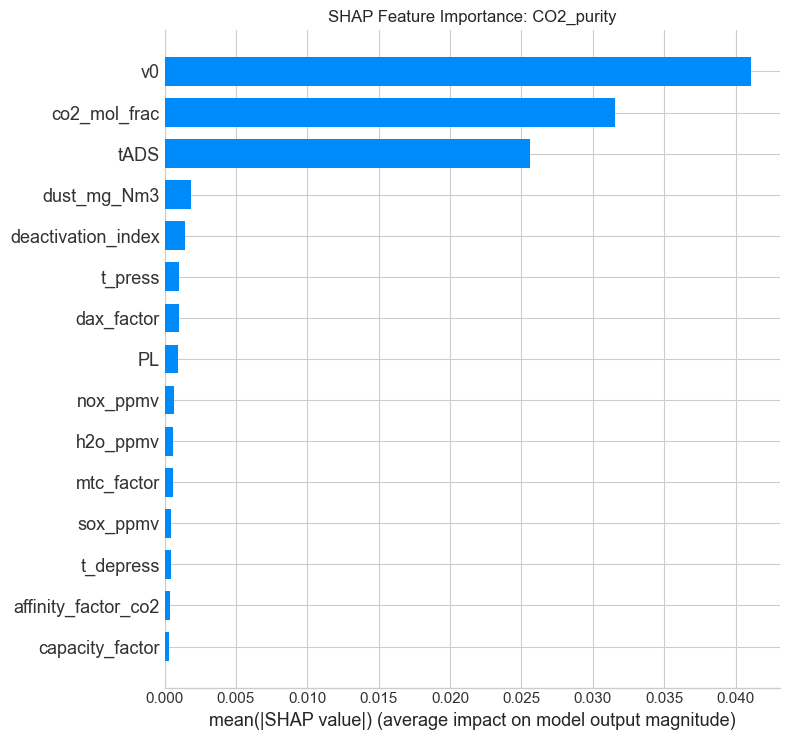

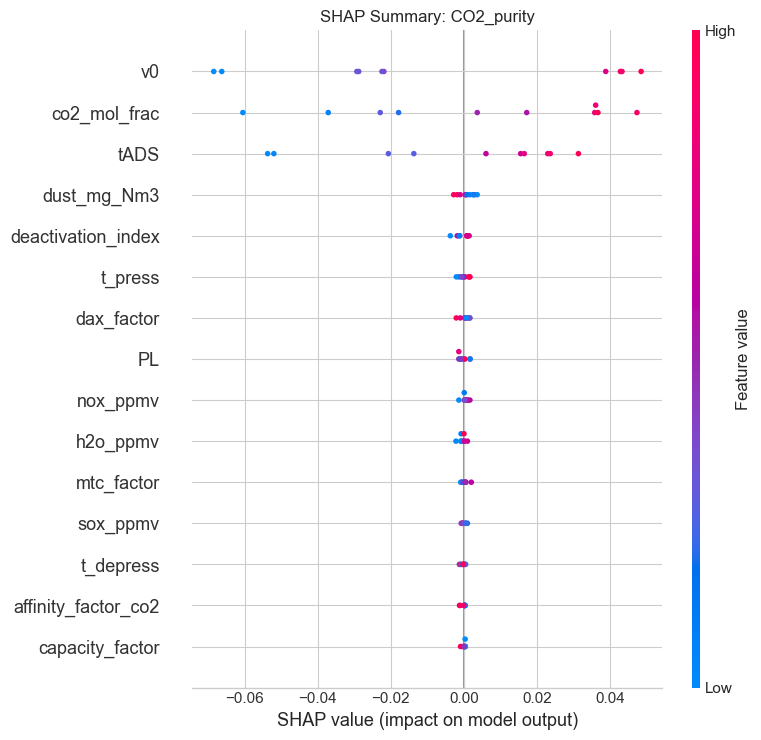

In [35]:
# SHAP summary for CO2_purity
shap.summary_plot(shap_values_purity, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance: CO2_purity')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_purity, X_test, show=False)
plt.title('SHAP Summary: CO2_purity')
plt.tight_layout()
plt.show()

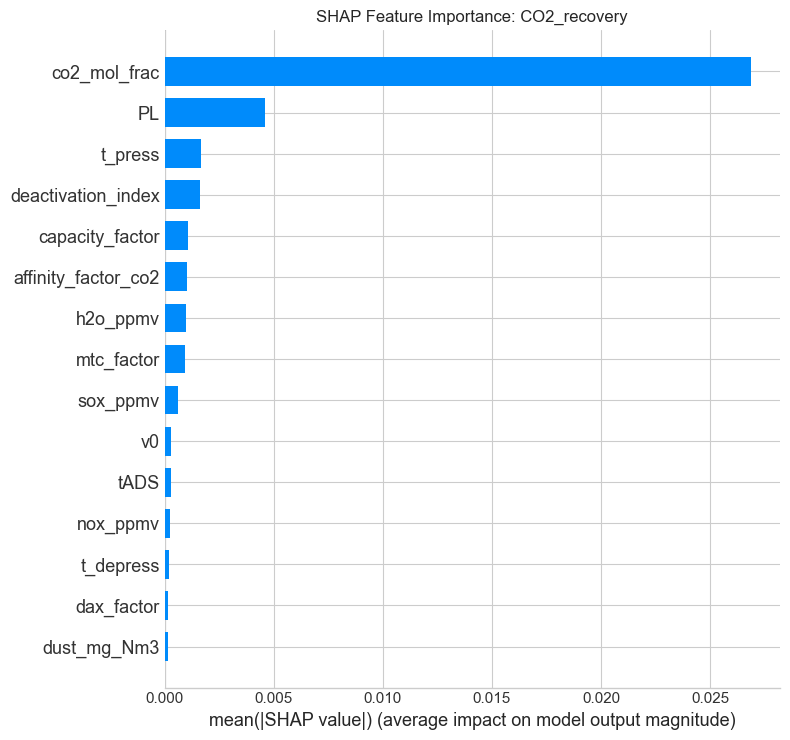

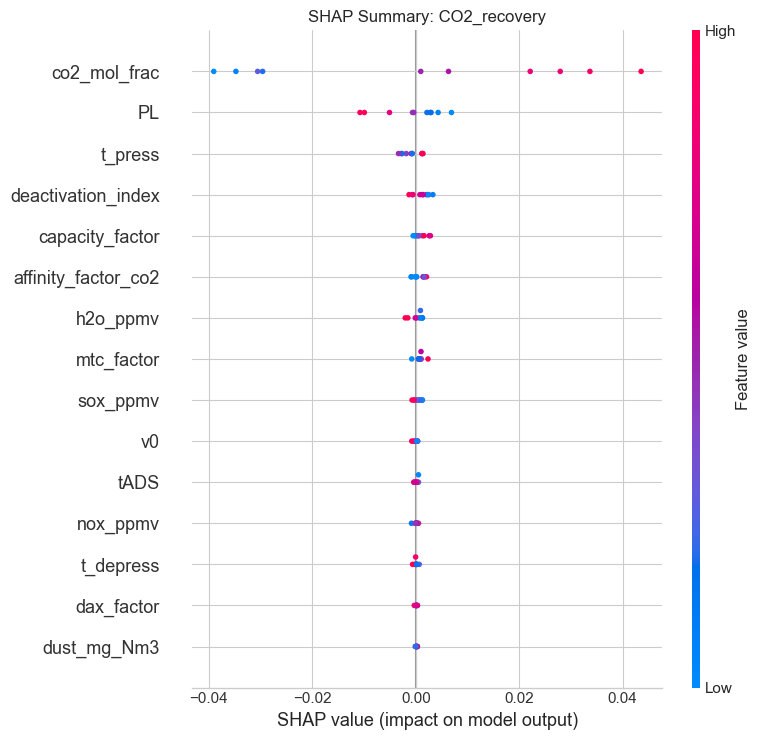

In [36]:
# SHAP summary for CO2_recovery
shap.summary_plot(shap_values_recovery, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance: CO2_recovery')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_recovery, X_test, show=False)
plt.title('SHAP Summary: CO2_recovery')
plt.tight_layout()
plt.show()

In [37]:
results_output_path = base_dir / 'model' / 'test_predictions.csv'
metrics_output_path = base_dir / 'model' / 'test_metrics.csv'

results_df.to_csv(results_output_path, index=False)
metrics_df.to_csv(metrics_output_path, index=False)

print(f'Saved predictions: {results_output_path}')
print(f'Saved metrics: {metrics_output_path}')

Saved predictions: C:\Users\junhyun111\Desktop\mf\model\test_predictions.csv
Saved metrics: C:\Users\junhyun111\Desktop\mf\model\test_metrics.csv
